# EDA (Exploratory Data Analysis) - Análisis exploratorio de datos: RRHH

**Repaso de todo lo aprendido en el curso**: Lectura de ficheros, exploración y limpieza (pandas), operaciones matemáticas (numpy) y visualización con matplotlib, seaborn y plotly

#### StoryTelling: Contexto

Formáis parte del equipo de análisis de datos del departamento de **Recursos Humanos** de una empresa.

Nos han exportado un extracto de la base de datos de personal (`data/empleados_rrhh.csv`) y dirección os pide un **informe exploratorio** para entender cómo está compuesta la plantilla antes de tomar decisiones (revisión salarial, plan de teletrabajo, etc.).

Como en cualquier dataset real, **los datos no llegan limpios**: habrá nulos, departamentos escritos de formas distintas y filas duplicadas. Vamos a seguir el proceso típico de un EDA:

1. Carga de datos
2. Primera exploración
3. Calidad de datos (nulos, duplicados, inconsistencias)
4. Limpieza
5. Análisis univariante (una variable) + visualización
6. Análisis bivariante (relación entre variables) + visualización
7. Correlación entre variables numéricas
8. Un gráfico interactivo con Plotly
9. Conclusiones

## 0. Importación de librerías y configuraciones iniciales

- Revisar que nuestro entorno de desarrollo está activado y que tenemos todas las librerías instaladas. 

In [262]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import requests as rq

sns.set_theme(style='whitegrid') #configurar el fondo de las gráficas

## 1. Carga de datos

Empezamos siempre igual, los datos o bien vienen de base de datos(mongo o mySQL), de una API(n8n o una API externa) o de un fichero. 

In [263]:
df = pd.read_csv('./data/empleados_rrhh.csv')
df.head()

,id_empleado,nombre,departamento,genero,edad,antiguedad_anios,salario_anual,satisfaccion,horas_extra_mes,teletrabajo
0,79,Beatriz Rubio,Marketing,Hombre,42.0,11.0,32852.78,6.0,18,False
1,151,Ana López,marketing,Hombre,47.0,11.0,36555.44,9.0,1,True
2,172,Teresa Ruiz,ventas,Mujer,52.0,14.0,38518.68,6.0,17,True
3,65,Pablo Blanco,RRHH,Mujer,35.0,8.0,27203.22,6.0,7,False
4,191,Silvia Gómez,VENTAS,Mujer,50.0,14.0,37651.75,5.0,17,True


## 2.Primera exploración

Antes de tocar nada, necesitamos entender qué tenemos entre manos:

    - Cuántas filas
    - Cuántas columnas
    - Tipos de datos
    - Dónde están los valores numéricos

In [264]:
print('Dimensiones (filas, clumnas)', df.shape)
df.info()

Dimensiones (filas, clumnas) (230, 10)
<class 'pandas.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_empleado       230 non-null    int64  
 1   nombre            230 non-null    str    
 2   departamento      230 non-null    str    
 3   genero            230 non-null    str    
 4   edad              219 non-null    float64
 5   antiguedad_anios  222 non-null    float64
 6   salario_anual     217 non-null    float64
 7   satisfaccion      224 non-null    float64
 8   horas_extra_mes   230 non-null    int64  
 9   teletrabajo       230 non-null    bool   
dtypes: bool(1), float64(4), int64(2), str(3)
memory usage: 16.5 KB


Dos cosas sobre df.info():
    - Hay columnas con valores no nulos < 230 -> Tenemos valores nulos o vacíos
    - Comprobar que no hay id_empleado duplicados

### Resumen estadístico: Todas las estadísticas típicas: media, mediana, mix, max, cuartiles, etc.  

In [265]:
df.describe() 
df['edad'].describe()#si quiero un resumen estadístico de una vble

count    219.000000
mean      42.132420
std       11.568139
min       22.000000
25%       32.000000
50%       42.000000
75%       52.000000
max       60.000000
Name: edad, dtype: float64

## 3. Calidad de los datos
Antes de limpiar, hay que **detectar** los problemas. Vamos a revisar la cantidad de nulos y duplicados. 

In [266]:
# 3.1 Nulos por columna
df.isnull().sum()

id_empleado          0
nombre               0
departamento         0
genero               0
edad                11
antiguedad_anios     8
salario_anual       13
satisfaccion         6
horas_extra_mes      0
teletrabajo          0
dtype: int64

In [267]:
# 3.2 Filas duplicadas (mismo empleado registrado más de una vez)
print('Filas duplicadas: ', df.duplicated().sum())

Filas duplicadas:  10


In [268]:
#3.3 ¿Cuántos valores distintos tiene "departamento"? Debería haber solo 5 (lo sé porque es mi empresa)
df['departamento'].value_counts()

departamento
IT            47
Ventas        45
Finanzas      30
Marketing     25
RRHH          19
it            10
marketing      6
 IT            6
VENTAS         5
finanzas       5
It             5
 Ventas        4
rrhh           4
 Marketing     4
MARKETING      3
FINANZAS       3
Rrhh           3
RRHH           3
ventas         2
Finanzas       1
Name: count, dtype: int64

Como sospechábamos, el mismo departamento aparece escrito de varias formas. Esto es muy habitual cuando los datos se han introducido o vienen de sistemas distintos.

## 4. Limpieza de datos

4.1 Normalizar la columna Departamento. Quitar espacios en blanco, mayúsculas y minúsculas.

In [269]:
df['departamento'] = df['departamento'].str.strip().str.upper()
print(df['departamento'])

0      MARKETING
1      MARKETING
2         VENTAS
3           RRHH
4         VENTAS
         ...    
225       VENTAS
226    MARKETING
227           IT
228     FINANZAS
229           IT
Name: departamento, Length: 230, dtype: str


In [270]:
# crear un diccionario de traducción con el nomre "bonito"
nombres_departamento = {
    'IT':'IT',
    'VENTAS': 'Ventas',
    'MARKETING':'Marketing',
    'RRHH': 'RRHH',
    'FINANZAS': 'Finanzas'
}

df['departamento'] = df['departamento'].replace(nombres_departamento)
df['departamento'].value_counts()

departamento
IT           68
Ventas       56
Finanzas     39
Marketing    38
RRHH         29
Name: count, dtype: int64

4.2 Eliminar duplicados

In [271]:
# ver lo datos duplicados

df[df.duplicated()]


,id_empleado,nombre,departamento,genero,edad,antiguedad_anios,salario_anual,satisfaccion,horas_extra_mes,teletrabajo
71,218,Pedro Sánchez,Finanzas,Mujer,60.0,7.0,35328.99,8.0,15,False
73,111,Pedro Álvarez,IT,Mujer,55.0,15.0,43432.72,8.0,18,False
90,160,Adrián Domínguez,Finanzas,Hombre,40.0,9.0,32802.00,4.0,4,False
99,120,Cristina Pérez,Ventas,Hombre,25.0,13.0,34784.37,8.0,10,False
101,48,Marta Delgado,IT,Hombre,50.0,6.0,37401.70,7.0,7,False
171,65,Pablo Blanco,RRHH,Mujer,35.0,8.0,27203.22,6.0,7,False
174,192,Marta Gil,Ventas,Hombre,58.0,6.0,21055.33,6.0,10,False
192,117,Nuria Ortega,Finanzas,Hombre,60.0,2.0,29375.70,6.0,5,False
202,184,Pedro Iglesias,Marketing,Mujer,26.0,14.0,41546.26,7.0,20,False
209,158,Adrián Álvarez,Ventas,Hombre,42.0,2.0,30791.40,5.0,17,False


In [272]:
df = df.drop_duplicates()
print('Filas tras eliminar duplicados', len(df))
print('Duplicado restante', df.duplicated().sum())

Filas tras eliminar duplicados 220
Duplicado restante 0


4.3 Tratar los valores nulos

No todos los valores nulos se tratan igual, depende de la columna y del tipo de dato. 
    - edad, antiguedad_anios, satisfaccion -> los rellenamos con la mediana (es la forma más robusta de estimar un valor "típico" sin que nos afecte a los extremos)
    - salario_anual -> En lugar de usar la mediana global, usamos la mediana pero solo del departamento. Usamos group by para agrupar por departamento.
    - nombre, apellidos son susceptible sde eliminarse. 

In [273]:
# edad, antiguedad y satisfacción -> mediana global
for columna in ['edad', 'antiguedad_anios', 'satisfaccion']:
    mediana = df[columna].median()
    df[columna] = df[columna].fillna(mediana)#fillna rellena los campos nulos/nan por la mediana de la edad


# salario -> mediana de todo el departamento
df['salario_anual'] = df['salario_anual'].fillna(
    df.groupby('departamento')['salario_anual'].transform('median')
)


#si tuviésemos que eliminar un registro con valor nulo:
# df = df.dropna() #elimina todos los registros que tengan algún valor nulo

#si quisiera eliminar todos los registros en base a una columna, ej:nombre
#df = df.dropna(subset=['nombre', 'apellidos'])

# si quiero eliminar directamente el campo de df sin tener que sobreescribirlo y crear un df nuevo:
# df.dropna(subset=['nombre'], inplace=True)






# comprobación final: no debería quedar ningún nulo
df.isnull().sum()

id_empleado         0
nombre              0
departamento        0
genero              0
edad                0
antiguedad_anios    0
salario_anual       0
satisfaccion        0
horas_extra_mes     0
teletrabajo         0
dtype: int64

### 5. Análisis Univiariante

5.1. Empleados por departamento

In [274]:
conteo_dpto = df['departamento'].value_counts() #contar los registros por dpto
print(conteo_dpto)

departamento
IT           66
Ventas       53
Marketing    37
Finanzas     36
RRHH         28
Name: count, dtype: int64


In [275]:
# falta el índice en el df

conteo_dpto = df['departamento'].value_counts().reset_index()
print(conteo_dpto)

  departamento  count
0           IT     66
1       Ventas     53
2    Marketing     37
3     Finanzas     36
4         RRHH     28


In [276]:
#renombrar la columna count
conteo_dpto.columns = ['departamento', 'cantidad']
print(conteo_dpto)

  departamento  cantidad
0           IT        66
1       Ventas        53
2    Marketing        37
3     Finanzas        36
4         RRHH        28


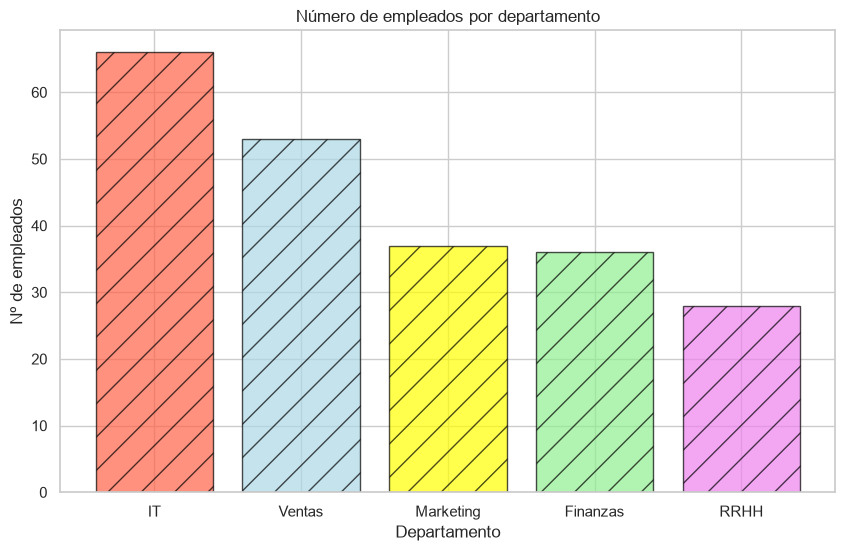

In [277]:
# la gráfica con matplotlib
plt.figure(figsize=(10,6))
plt.title('Número de empleados por departamento')
plt.bar(conteo_dpto['departamento'], conteo_dpto['cantidad'], alpha=0.7, edgecolor='black', color=['tomato', 'lightblue', 'yellow', 'lightgreen','violet'], hatch='/')
plt.xlabel('Departamento')
plt.ylabel('Nº de empleados')
plt.show()

Conclusiones sobre la gráfica: Si hubiera que despedir a gente, el departamento de IT sería el que menor impacto tendría porque es donde hay más plantilla y despidiendo a un 10%, los trabajadores restantes pueden asumir el trabajo y no se resienten tanto los ingresos de la empresa

5.2 Distribución de la edad

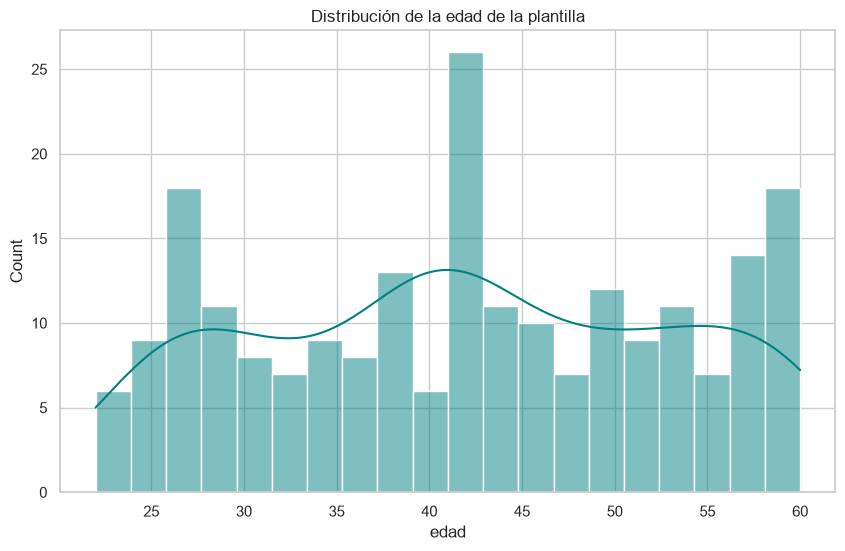

In [278]:
plt.figure(figsize=(10,6))
plt.title('Distribución de la edad de la plantilla')
sns.histplot(data = df, x='edad', kde='True', color='teal', bins=20)
plt.show()

Si tengo que despedir a gente, el rango central es el que más se verá afectado. Esto suele ocurrir en las empresas porque la gente joven se va más fácilmente, la gente de mediana edad si está a gusto en una empresa no renuncia a eso aunque le ofrezcan más sueldo en otro sitio. Es bastante injusto porque la franja de edad media es precisamente la que más dificultad puede encontrar para encontrar trabajo. 

5.3 Distribución del salario

Vamos a usar boxplot porque nos permite ver la mediana, rango intercuartílico y valores atípicos. 

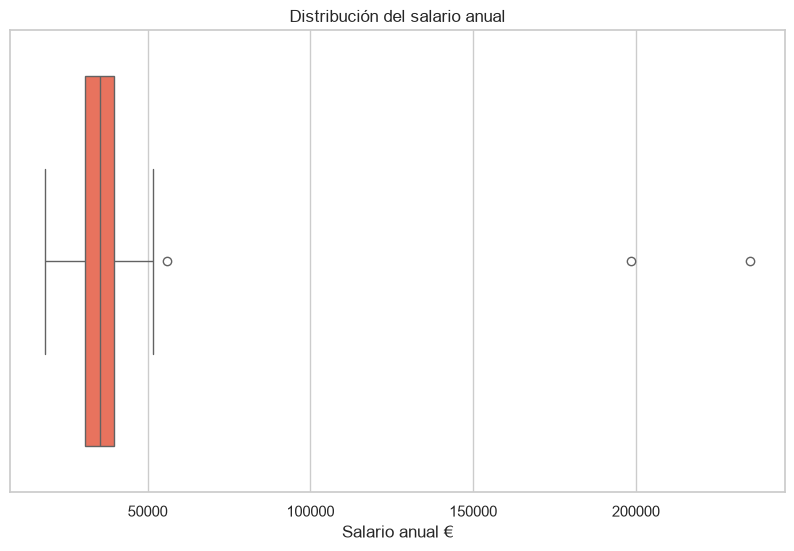

In [279]:
plt.figure(figsize=(10,6))
plt.title('Distribución del salario anual')
plt.xlabel('Salario anual €')
sns.boxplot(data=df, x='salario_anual', color='tomato')
plt.show()

In [280]:
# ¿Quiénes son esos salario outliers que se salen de rango?

#Hago un filtro con los empleados cuyo salario es > 100000
df[ df['salario_anual'] > 100000] [['nombre', 'departamento', 'antiguedad_anios', 'salario_anual'] ]




,nombre,departamento,antiguedad_anios,salario_anual
50,Javier Moreno,Finanzas,15.0,235000.0
83,Andrea Gómez,Finanzas,4.0,198500.0


In [281]:
#Salario medio:
df['salario_anual'].mean().round(2)

np.float64(36902.47)

5.4. Reparto por género

Vamos a usar un diagrama de tarta

In [282]:
conteo_genero = df['genero'].value_counts()
print(conteo_genero)

genero
Hombre    118
Mujer     102
Name: count, dtype: int64


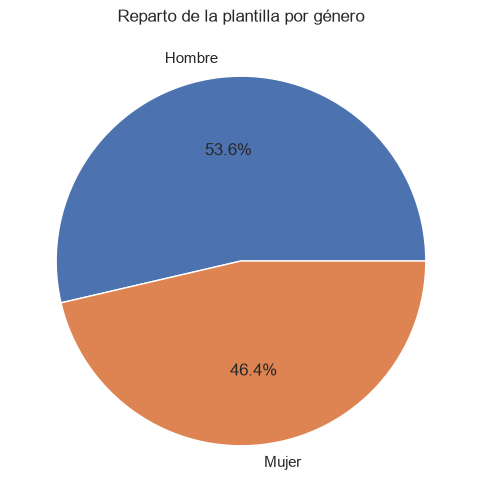

In [283]:
plt.figure(figsize=(6,6))
plt.title('Reparto de la plantilla por género')
plt.pie(
    conteo_genero,
    labels=conteo_genero.index,
    autopct='%1.1f%%'
)

plt.show()

## 6. Análisis Bivariante

Vamos a cruzar variables entre sí para establecer relaciones.

6.1 Salario medio por departamento.

In [284]:
salario_medio_dpto = (
    df.groupby('departamento')['salario_anual'] #agrupo todos los salarios por dpto, hago la media  para cada uno con un redondendo de 2 caracteres
    .mean()
    .round(2)
    .reset_index() #le agrego índices al nuevo df
    .sort_values('salario_anual', ascending=True)
)

#salario_medio_dpto

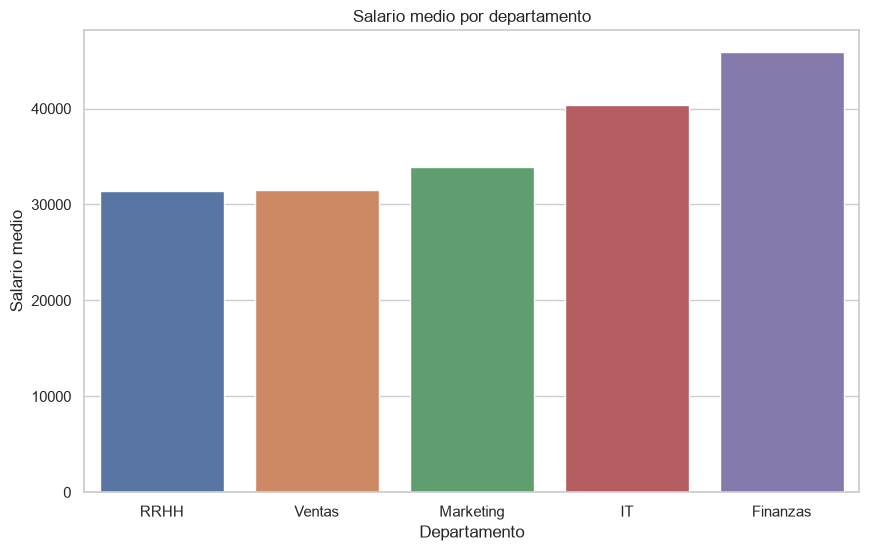

,departamento,salario_anual
3,RRHH,31449.90
4,Ventas,31478.43
2,Marketing,33945.89
1,IT,40338.71
0,Finanzas,45867.66


In [285]:
# La gráfica --> diagrama de barras con seaborn

plt.figure(figsize=(10,6))
plt.title('Salario medio por departamento')
sns.barplot(data=salario_medio_dpto, x='departamento', y='salario_anual',hue='departamento', legend=False)
#hue asigna un color a cada categoría
## legend=False es para que no dé el error al poner las etiquetas en los ejes, a veces falla sin eso. 
plt.xlabel('Departamento')
plt.ylabel('Salario medio')
plt.show()

salario_medio_dpto

6.2 Relación entre edad y salario

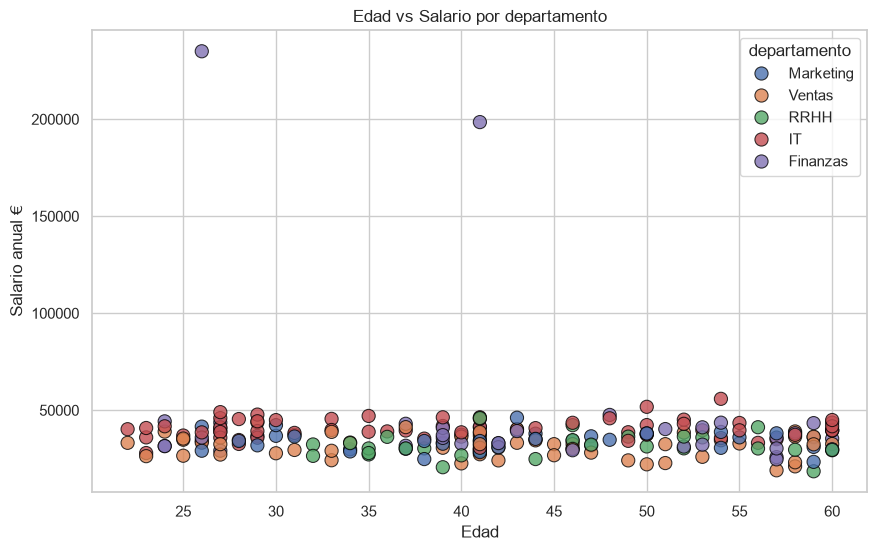

In [286]:
# Vamos a hacer un diagrama de puntos, scatterplot
plt.figure(figsize=(10,6))
plt.title('Edad vs Salario por departamento')
sns.scatterplot(data=df,x='edad',y='salario_anual', hue='departamento', s=90, alpha=0.8, edgecolor='black')
plt.xlabel('Edad')
plt.ylabel('Salario anual €')

plt.show()

Vemos que no hay grandes diferencias salariales entre dptos y que el todos los salarios están en un rango aprox. de entre 0- 50.000€. No hay un mal reparto de la masa salarial, estamos haciendo las cosas bien

6.3 ¿Influye el teletrabajo en la satisfacción de los trabajadores?

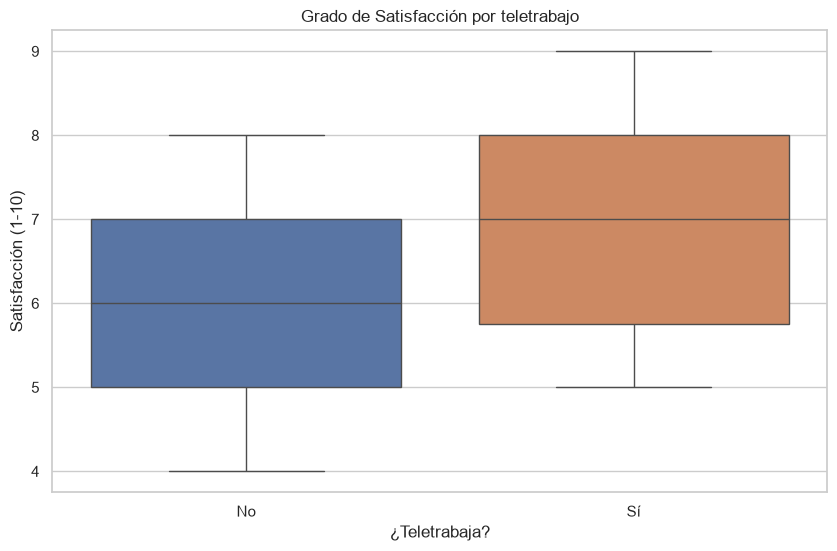

In [287]:
plt.figure(figsize=(10,6))
plt.title('Grado de Satisfacción por teletrabajo')
sns.boxplot(data=df,x='teletrabajo',y='satisfaccion', hue='teletrabajo', legend=False)
plt.xlabel('¿Teletrabaja?')
plt.ylabel('Satisfacción (1-10)')
plt.xticks([False, True], ['No', 'Sí']) #sustituye el valor de las cajas para los datos originales por NO / Sí

plt.show()

El grado de satisfacción medio de los que no teletrabajan está en 6 y de los que sí lo hacen, está en 7. 

## 7. Correlación entre variables numéricas.

La matriz de correlación nos dice, de un vistazo, qué variables numéricas están linealmente relacionadas. 

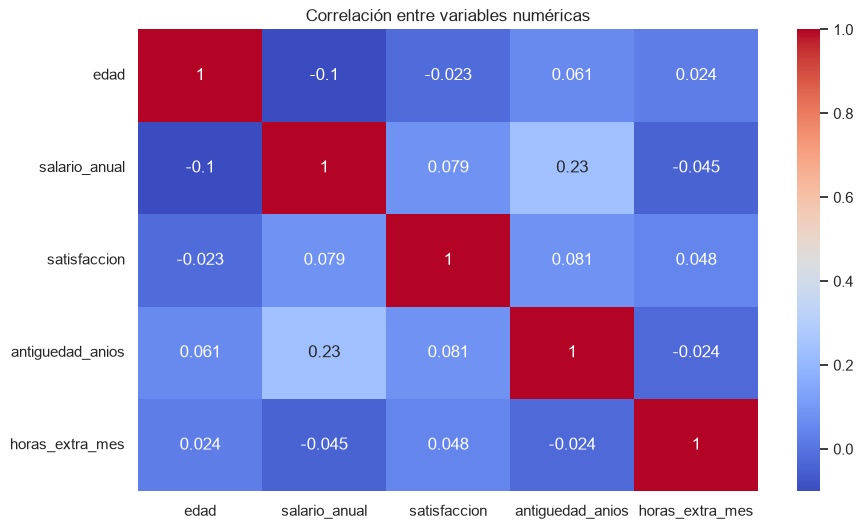

In [288]:
columnas_numericas = ['edad', 'salario_anual', 'satisfaccion', 'antiguedad_anios', 'horas_extra_mes']

matriz_correlacion = df[columnas_numericas].corr()
matriz_correlacion

plt.figure(figsize=(10,6))
plt.title('Correlación entre variables numéricas')
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm')
plt.show()

Vemos la relación lineal entre todas las variables numéricas, aunque en este caso salen todos los valores muy próximos a cero. No aporta mucho a la hora de tomar. decisiones. La relación más fuerte está entre la antigüedad y el salario

## 8. Gráfico interactivo con Plotly

Con Plotly podemos crear el mismo tipo de gráficos pero **interactivos**. 

In [289]:
fig = px.box(
    df,
    x='departamento',
    y='salario_anual',
    color='departamento',
    points='all', #para mostrar cada punto al lado del gráfico de caja
    title='Distribución del salario por departamento',
    labels={'departamento': 'Departamento', 'salario_anual': 'Salario anual (€)'}
)


fig.show()

Si pincho sobre Finanzas desaparece y veo los otros más claros. Me pregunto si no habría que haber hecho el estudio quitando los dos outliers

## Resumen de funciones utilizadas

| Función / Sintaxis | ¿Para qué sirve? |
|---|---|
| `pd.read_csv()` | Cargar los datos |
| `df.shape` / `df.info()` / `df.describe()` | Primera exploración |
| `df.isnull().sum()` | Contar nulos por columna |
| `df.duplicated()` / `df.drop_duplicates()` | Detectar y eliminar duplicados |
| `df[col].value_counts()` | Distribución de una columna categórica |
| `.str.strip()` / `.str.upper()` / `.replace()` | Normalizar texto |
| `df[col].fillna(valor)` | Rellenar nulos |
| `df.groupby(col).transform()` | Rellenar nulos con un valor por grupo |
| `df.astype()` | Cambiar el tipo de una columna |
| `sns.barplot` / `sns.histplot` / `sns.boxplot` / `sns.scatterplot` / `sns.heatmap` | Visualización estática (seaborn) |
| `plt.pie` | Gráfico de sectores (matplotlib) |
| `df[cols].corr()` | Matriz de correlación |
| `px.box` | Gráfico interactivo (plotly) |
| `requests.get()` / `requests.post()` | Llamar a un webhook de n8n (traer datos / enviar el informe) |

## 9. Conclusiones



In [290]:
json_data = df.to_json(orient = "records") #para que cada registro sea un elemento del json

resumen = {
    "fecha_informe": pd.Timestamp.today().strftime('%d-%m-%Y %H:%M'),
    "total_empleados": len(df),
    "salario_medio": float(df['salario_anual'].mean().round(2)),
    "departamento_mas_grande": df['departamento'].value_counts().idxmax(),
    "numero_empleados_departamento_mas_grande":  int(df['departamento'].value_counts().max()),
    "empleados_hacen_teletrabajo": f"{int(df['teletrabajo'].mean() * 100)}%",
    "data": json_data
}

## paso este resumen a un nodo de IA (16 de n8n) y quiero que me devuelva unas conclusionies en texto


URL_INFORME = "https://lara.n8ncamp.com/webhook-test/montar_informe"
response = rq.post(URL_INFORME,json=resumen)
conclusiones = response.json()
fichero = open('./data/conclusiones.txt', 'w', encoding='utf-8')
fichero.write(conclusiones['mensaje'])
fichero.close()



